# Tutorial de Modelagem Sísmica com Devito

### Objetivo

Este tutorial tem como objetivo demonstrar os conceitos básicos da modelagem sísmica usando a equação da onda acústica. Utilizaremos o Devito, um framework baseado em Python para geração de código otimizado e solução de equações diferenciais parciais (PDEs), para criar um modelo sísmico simples em 2D.

### Pré-requisitos
- Conhecimento básico de Python;
- Noções básicas de equações diferenciais e métodos numéricos;
- Devito e suas dependências devem estar instalados.

### Inspiração

Este tutorial foi inspirado nos tutoriais apresentados pela Equipe do Devito em: https://www.devitoproject.org/examples/seismic/tutorials/01_modelling.html

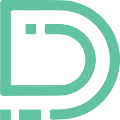


# Introdução à Modelagem Sísmica

Neste exemplo, nosso objetivo é destacar as ideias fundamentais por trás da modelagem sísmica, onde criaremos um modelo numérico que captura os processos envolvidos em uma aquisição sísmica. Este modelo direto (forward) formará a base para o aprendizado sobre a implementação de processos de inversão utilizando operadores do Devito.

A *base teórica* que embasará esta análise foi extraída de:
- José M. Carcione, Gérard C. Herman, and A. P. E. ten Kroode, (2002), "Seismic modeling," GEOPHYSICS 67: 1304-1325. Disponível em https://doi.org/10.1190/1.1500393.

## Conceitos fundamentais:

- A modelagem sísmica numérica é uma técnica para simular a propagação de ondas no subsolo;
- O objetivo é prever o sismograma que um conjunto de sensores registraria, dada uma estrutura assumida para a subsuperfície;
- Ferramenta valiosa para a interpretação sísmica e uma parte essencial dos algoritmos de inversão sísmica.
- Aplicação importante na avaliação e planejamento de aquisições sísmicas.

Existem **diversas abordagens para a modelagem sísmica**. Podemos classificá-las em três categorias principais:


1. *Métodos Diretos*
- **Como funcionam:** Discretizam o modelo geológico em uma malha numérica e resolvem a equação da onda diretamente em cada ponto.
- **Vantagens:** São muito precisos (com malhas refinadas), não possuem restrições quanto à complexidade do modelo geológico e permitem visualizar o campo de onda completo (instantâneos ou snapshots).
- **Desvantagem:** São computacionalmente mais custosos que as outras abordagens.

2. *Métodos de Equação Integral*
- **Como funcionam:** Baseiam-se no Princípio de Huygens, representando o campo de onda como uma soma (sobreposição) de ondas geradas por fontes pontuais em volumes ou superfícies.
- **Vantagens:** São muito eficientes e precisos para geometrias específicas, como objetos em meios homogêneos ou modelos com muitas fraturas.
- **Desvantagem:** Sua aplicação é mais restrita quando comparada aos métodos diretos.

3. *Métodos de Traçado de Raios (Assintóticos)*
- **Como funcionam:** São aproximativos e modelam a onda como um conjunto de "raios" ou "eventos" individuais, cada um com seu tempo de chegada e amplitude.
- **Vantagem:** São os métodos mais eficientes e rápidos, especialmente para modelos tridimensionais grandes.
- **Desvantagem:** Não consideram o campo de onda completo, sendo menos precisos por serem uma aproximação.

## Fluxo de Trabalho da Modelagem

O processo central que pretendemos modelar é uma aquisição sísmica, que consiste em dois componentes principais:

-   **Fonte** - Uma fonte é posicionada em uma ou poucas localizações físicas onde pressão artificial é injetada no domínio que queremos modelar. No caso de aquisição terrestre, geralmente é dinamite explodindo em uma localização específica, ou um vibroseis (um motor vibratório que gera ondas sonoras contínuas). Para uma aquisição marinha, a fonte é um canhão de ar que envia uma bolha de ar comprimido para a água, que se expande e gera uma onda sísmica.

-   **Receptor** -  Um conjunto de microfones ou hidrofones é usado para medir a onda resultante e criar um conjunto de medidas chamado de *Shot Record*(Registro sísmico). Essas medidas são registradas em múltiplas localizações, geralmente na superfície do domínio ou no fundo do oceano em alguns casos marinhos.

Para criar um modelo numérico de uma aquisição sísmica, precisamos:

1. Resolver a equação da onda;
2. Implementar a interpolação de fonte e receptor para injetar a fonte e registrar a onda sísmica em pontos esparsos na malha computacional.

## A Equação da onda sísmica acústica

A equação da onda acústica para a vagarosidade ao quadrado $m$, definida como:

\begin{equation}
    m=\frac{1}{c^2}
\end{equation}

onde $c$ é a velocidade do som no meio físico em questão, e para uma fonte $q$, é dada por:

\begin{cases}
    &m \frac{d^2 u(x,t)}{dt^2} - \nabla^2 u(x,t) = q \ \text{in } \Omega \\
    &u(.,t=0) = 0 \\
    &\frac{d u(x,t)}{dt}|_{t=0} = 0
\end{cases}

com condições iniciais nulas para garantir a unicidade da solução.

As condições de contorno são do tipo Dirichlet:

\begin{equation}
u(x,t)|_{\delta\Omega} = 0
\end{equation}

onde $\delta\Omega$ é a superfície que delimita o modelo $\Omega$.

# Domínios finitos

A última peça do quebra-cabeça é a limitação computacional.

No campo, a onda sísmica se propaga em todas as direções até uma distância “infinita”. No entanto, resolver a equação da onda em um **domínio infinito de forma matemática/discreta não é viável**. 

Para compensar isso, são necessárias Condições de Contorno Absorventes (ABC – Absorbing Boundary Conditions) ou Camadas Perfeitamente Casadas (PML – Perfectly Matched Layers) para **imitar um domínio infinito**. 

Esses dois métodos permitem aproximar um meio infinito atenuando e absorvendo as ondas no limite do domínio para evitar reflexões.

O mais simples desses métodos é a máscara de amortecimento absorvente.
A ideia central é estender o domínio físico e adicionar, nessa extensão, uma “máscara esponja” (Sponge mask) que absorverá as ondas incidentes.


A equação da onda acústica com essa máscara de amortecimento pode ser reescrita como:

\begin{cases}
    &m \frac{d^2 u(x,t)}{dt^2} - \nabla^2 u(x,t) + \eta \frac{d u(x,t)}{dt}=q  \ \text{in } \Omega \\
    &u(.,0) = 0 \\
    &\frac{d u(x,t)}{dt}|_{t=0} = 0
\end{cases}

where $\eta$ is the damping mask equal to $0$ inside the physical domain and increasing inside the sponge layer. 

Multiple choice of profile can be chosen for $\eta$ from linear to exponential.

# Modelagem Sísmica com Devito

Descrevemos aqui a configuração passo a passo da modelagem sísmica com Devito em um caso simples 2D. Criaremos um modelo físico do nosso domínio e definiremos uma única fonte e um conjunto correspondente de receptores para modelar o modelo direto (forward), como ilustrado abaixo:

![image.png](https://www.devitoproject.org/examples/seismic/tutorials/survey-ship-diagram.png)

## Importando bibliotecas do python

In [64]:
#NBVAL_IGNORE_OUTPUT
# Adding ignore due to (probably an np notebook magic) bug
import numpy as np
import matplotlib.pyplot as plt
from examples.seismic import Model, plot_velocity,plot_shotrecord,RickerSource,TimeAxis, Receiver

from devito import TimeFunction,Eq, solve,Operator

%matplotlib inline

## Defining o problema físico

O problema físico que será representado foi extraído da seguinte referência:
- Ji, L., Lin, M. Numerical Analysis of the Effect of Mesoscale Eddies on Seismic Imaging. Pure Appl. Geophys. 170, 259–270 (2013). https://doi.org/10.1007/s00024-012-0497-1


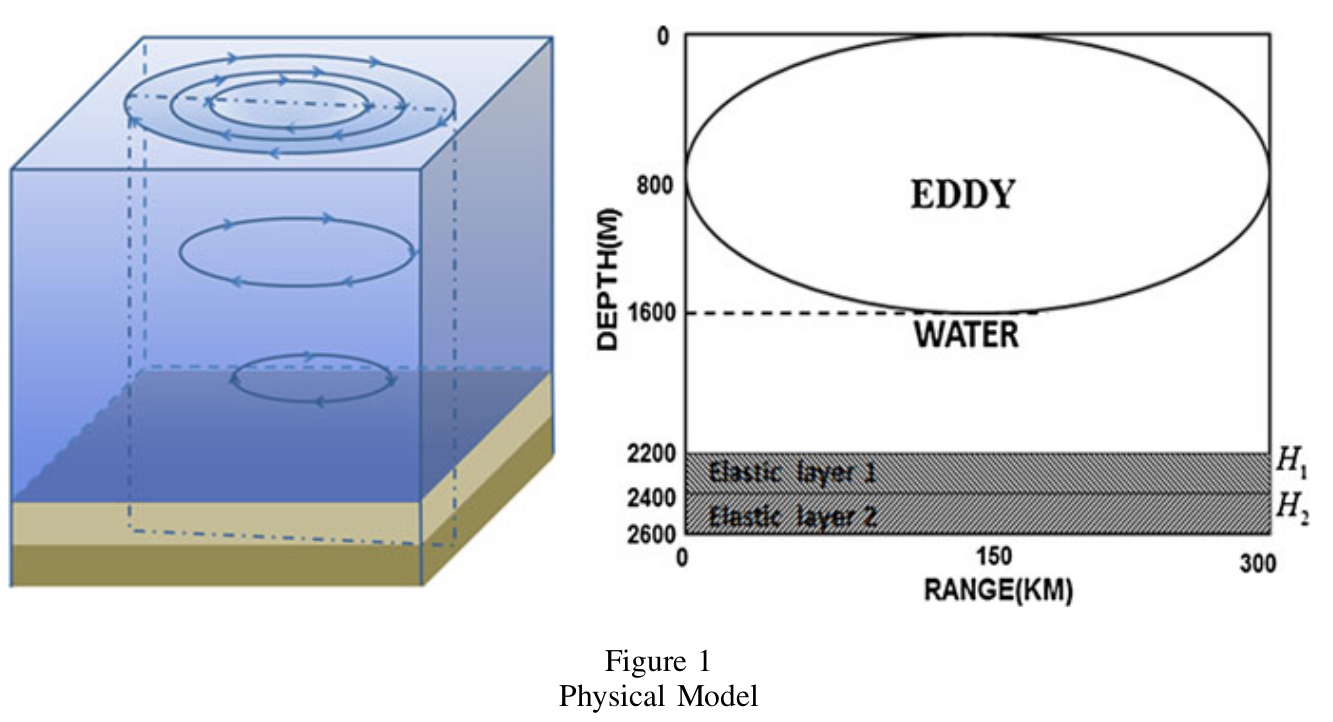

O primeiro passo é definir o modelo físico:

- Quais são as dimensões físicas de interesse?
- Qual é o perfil de velocidade deste domínio físico?

Vamos criar um modelo de velocidade simples manualmente para fins de demonstração de fundamentos básicos de Oceanografia Física.

Este modelo consiste essencialmente em 5 camadas (3 para a coluna d'água e 2 para embasamento - sedimento e rocha), cada uma com sua respectiva velocidade:

1. Velocidade de 1.520 $m/s$ na **Camada de Mistura**;

2. Zona de baixa velocidade na **Termoclina** com 1.480 $m/s$;

3. Velocidade de 1.520 $m/s$ na **Camada isotérmica de fundo**.

4. Velocidade de 2.000 $m/s$ na **Camada de sedimentos**.

5. Velocidade de 4.000 $m/s$ na **Camada de embasamento rochoso**.


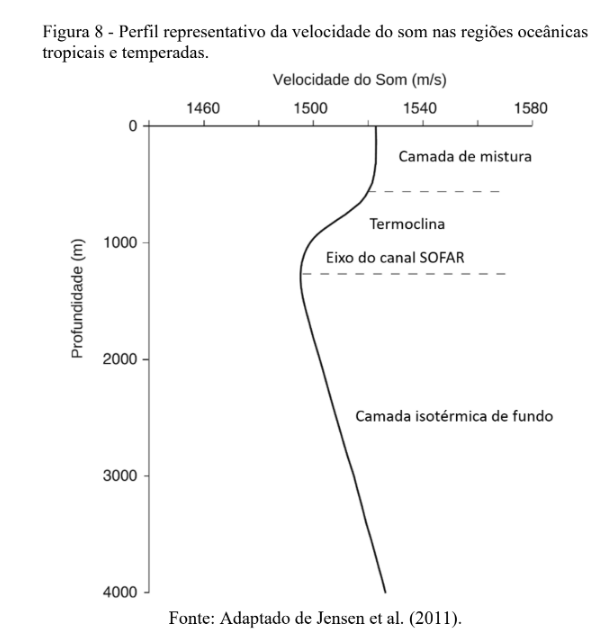

In [165]:
# Define o tamanho físico do modelo
shape = (4400, 3000)  # Número de pontos da malha (nx, nz)
spacing = (1, 1)  # Espaçamento da malha em metros. O tamanho do domínio é agora 4.4km x 3km
origin = (-0.2, -0.2)  # Localização do canto superior esquerdo. Isto é necessário para definir
# a localização absoluta da fonte e dos receptores

# Define um perfil de velocidade. A velocidade está em km/s
v = np.empty(shape, dtype=np.float32)
v[:, :2001] = 1.52
v[:, 2001:] = 2.0
v[:, 2201:] = 4.0

# Adiciona camada de baixa velocidade (termohalina) no meio da coluna de água
# Por exemplo, de z=400 m a 1000 m => índices 40 a 100
v[:, 400:1000] = 1.48

# Com a velocidade e tamanho do modelo definidos, podemos criar o modelo sísmico que
# encapsula estas propriedades. Também definimos o tamanho da camada absorvedora como 20 pontos de malha
model = Model(vp=v, origin=origin, shape=shape, spacing=spacing, space_order=2, nbl=200, bcs="damp")

Operator `initdamp` ran in 0.01 s


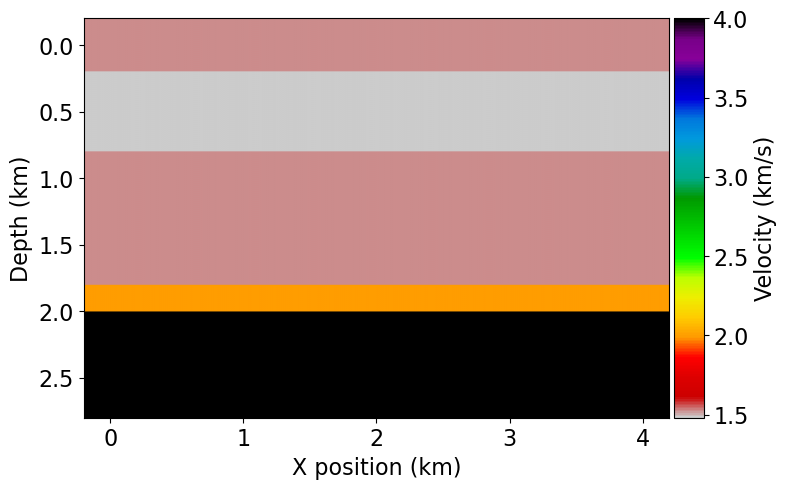

In [166]:
# Graficando o modelo de velicidade
plot_velocity(model, cmap='nipy_spectral_r')

# Geometria de aquisição

Para definir completamente a configuração do nosso problema, também precisamos definir a fonte que injeta a onda no modelo e o conjunto de locais dos receptores nos quais o campo de onda será amostrado.

A assinatura temporal da fonte será modelada usando uma *onda Ricker* (Wavelet de fase zero, a segunda derivada da função gaussiana ou a terceira derivada da função densidade de probabilidade normal), definida como:

\begin{equation}
  q(t) = (1-2\pi^2 f_0^2 (t - \frac{1}{f_0})^2 )e^{- \pi^2 f_0^2 (t - \frac{1}{f_0})}
\end{equation}

Para definir completamente a assinatura da fonte, primeiro precisamos definir a duração temporal do nosso modelo e o tamanho do passo de tempo, que é determinado pela condição de CFL e pelo espaçamento da malha.

Condição de CFL (Courant–Friedrichs–Lewy)

É uma condição de estabilidade numérica que liga:

- a velocidade de propagação das ondas no seu modelo ($v$)
- o passo de tempo da simulação ($\Delta t$); e
- o espaçamento da malha ($\Delta x,\Delta z$, etc)

Para métodos explícitos (como diferenças finitas na equação da onda), existe um limite máximo para $\Delta t$: 
- se o passo de tempo for muito grande em relação ao espaçamento da malha, a solução “explode” ou fica instável.
  
Felizmente, a utilidade `Model` fornece o passo de tempo crítico, de modo que podemos discretizar totalmente o eixo de tempo do modelo como um array `time_range`.

In [167]:
t0 = 0.  # Simulação começa em t=0
tn = 1592.  # Simulação dura 2 segundos (2000 ms)
dt = model.critical_dt  # Passo de tempo a partir do espaçamento da grade do modelo

time_range = TimeAxis(start=t0, stop=tn, step=dt)

A fonte é posicionada à 50 metros de profundidade no meio do arranjo ($x_{src} = 2000m$), com um pico de frequência de 10 Hz.

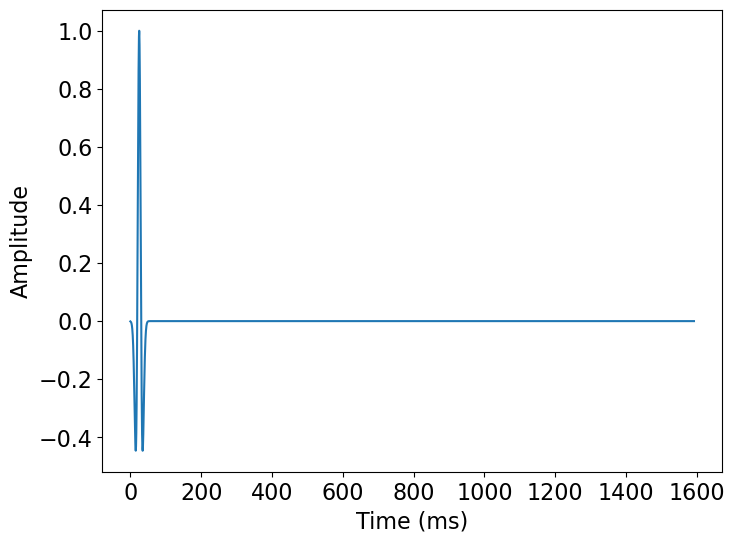

In [168]:
f0 = 0.04  # Pico de frequência da fonte é 40 Hz (0.040 kHz)
src = RickerSource(name='src', grid=model.grid, f0=f0,npoint=1, time_range=time_range)

# A posição da fonte: 
src.coordinates.data[0, :] = np.array(model.domain_size) * .5 # Meio do perfil
src.coordinates.data[0, -1] = 50.  # Depth is 50 m

# Graficando a assinatura da wavelet:
src.show()

In [169]:
src.coordinates_data

array([[2199.5,   50. ]], dtype=float32)

De forma semelhante ao nosso objeto de fonte, podemos agora definir nossa geometria de receptores como um símbolo do tipo `Receiver`. Vale notar aqui que ambas as classes utilitárias, `RickerSource` e `Receiver`, são "wrappers" simples em torno do tipo `SparseTimeFunction` do Devito, que encapsula dados pontuais esparsos e nos permite injetar e interpolar valores dentro e fora da malha computacional. Como já vimos, ambos os tipos fornecem uma propriedade `.coordinates` para definir a posição dentro do domínio de todos os pontos encapsulados por esse símbolo.

Neste exemplo, posicionaremos os receptores na mesma profundidade que a fonte, a cada $15m$ ao longo do eixo x. A propriedade `rec.data` será inicializada, mas deixada vazia, pois calcularemos as leituras dos receptores durante a simulação.

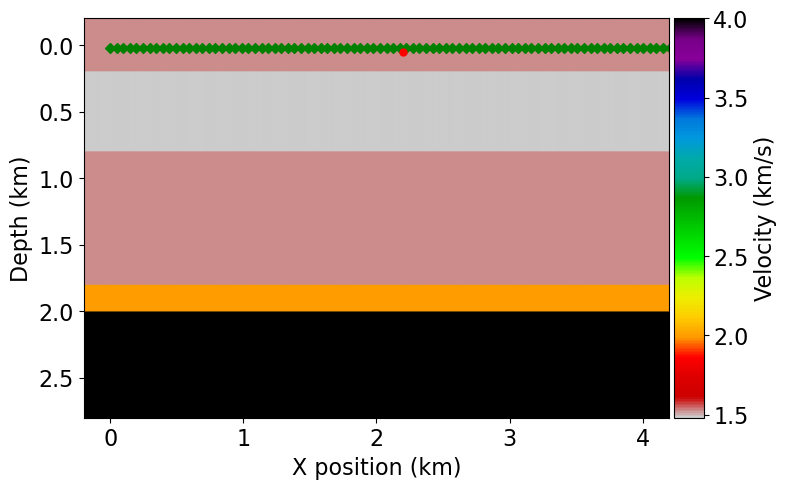

In [170]:
# Número de receptores
nrec = 90

# Criando um símbola para os receptores
rec = Receiver(name='rec', grid=model.grid, npoint=nrec, time_range=time_range)

# Receptores espaçado igualmente ao longo do eixo X
rec.coordinates.data[:, 0] = np.linspace(0, model.domain_size[0], num=nrec)
rec.coordinates.data[:, -1] = 20.  # Depth is 20 m

# Gráfico com fonte e receptores dentro do domínio:
# Ponto vermelho: Localização da Fonte
# Pontos verdes: Localizações dos receptor
plot_velocity(model, source=src.coordinates.data,receiver=rec.coordinates.data,cmap='nipy_spectral_r')

# Discretização por Diferenças Finitas

O Devito é uma DSL (Linguagem de Domínio Específico) de diferenças finitas que resolve a equação de onda discretizada em uma malha cartesiana. A aproximação por diferenças finitas é derivada das expansões de Taylor do campo contínuo após a remoção do termo de erro.

## Discretização Temporal

Consideramos apenas a discretização temporal de segunda ordem por enquanto. A partir da expansão de Taylor, a aproximação discreta de segunda ordem para a derivada temporal de segunda ordem é:

\begin{equation}
\begin{aligned}
    \frac{d^2 u(x,t)}{dt^2} = \frac{\mathbf{u}(\mathbf{x},\mathbf{t+\Delta t}) - 2 \mathbf{u}(\mathbf{x},\mathbf{t}) + \mathbf{u}(\mathbf{x},\mathbf{t-\Delta t})}{\mathbf{\Delta t}^2} + O(\mathbf{\Delta t}^2).
\end{aligned}
\end{equation}

onde $\mathbf{u}$ é o campo de onda discreto, $\mathbf{\Delta t}$ é o passo de tempo discreto (distância entre dois pontos de tempo discretos consecutivos) e $O(\mathbf{\Delta t}^2)$ é o termo de erro de discretização.

A aproximação discretizada da derivada temporal de segunda ordem é então obtida descartando o termo de erro. Esta derivada é representada no Devito por `u.dt2`, onde u é um objeto `TimeFunction`.

## Discretização espacial

Definimos o Laplaciano discreto como a soma das derivadas espaciais de segunda ordem nas três dimensões:

\begin{equation}
\begin{aligned}
\Delta \mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t})= \sum_{j=1}^{j=\frac{k}{2}} \Bigg[\alpha_j \Bigg(&
\mathbf{u}(\mathbf{x+jdx},\mathbf{y},\mathbf{z},\mathbf{t})+\mathbf{u}(\mathbf{x-jdx},\mathbf{y},\mathbf{z},\mathbf{t}) + \\
&\mathbf{u}(\mathbf{x},\mathbf{y+jdy},\mathbf{z},\mathbf{t})+\mathbf{u}(\mathbf{x},\mathbf{y-jdy},\mathbf{z}\mathbf{t}) + \\
&\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z+jdz},\mathbf{t})+\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z-jdz},\mathbf{t})\Bigg) \Bigg] + \\
&3\alpha_0 \mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}).
\end{aligned}
\end{equation}

Esta derivada é representada no Devito por `u.laplace`, onde u é um objeto `TimeFunction`.

## Equação da Onda

Com a discretização espacial e temporal definidas, podemos discretizar completamente a equação da onda combinando as discretizações de tempo e espaço e obter o seguinte estêncil discreto de segunda ordem no tempo e de ordem $k^{th}$ no espaço para atualizar um ponto da malha na posição $x,y,z$ no tempo $t$, ou seja:

\begin{equation}
\begin{aligned}
\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t+\Delta t}) = &2\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) - \mathbf{u}(\mathbf{x},\mathbf{y}, \mathbf{z},\mathbf{t-\Delta t}) +\\
& \frac{\mathbf{\Delta t}^2}{\mathbf{m(\mathbf{x},\mathbf{y},\mathbf{z})}} \Big(\Delta \mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) + \mathbf{q}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) \Big).
\end{aligned}
\end{equation}

Para representar o campo de onda $u$ e a lentidão ao quadrado $m$, precisamos de objetos simbólicos correspondentes a campo variável no tempo-espaço `(u, TimeFunction)` e campo variável no espaço `(m, Function)`:

In [171]:
# Define o campo de onda com o tamanho do modelo e a dimensão temporal
u = TimeFunction(name="u", grid=model.grid, time_order=2, space_order=2)

# Podemos agora escrever a EDP (Equação Diferencial Parcial)
pde = model.m * u.dt2 - u.laplace + model.damp * u.dt

# A representação da EDP fica igual à forma teórica (como no papel)
pde

damp(x, y)*Derivative(u(t, x, y), t) - Derivative(u(t, x, y), (x, 2)) - Derivative(u(t, x, y), (y, 2)) + Derivative(u(t, x, y), (t, 2))/vp(x, y)**2

Explicação dos Componentes:

- `model.m`: Representa a lentidão ao quadrado ($m=1/c^{2}$) do meio
- `u.dt2`: Derivada temporal de segunda ordem ($\frac{\partial^{2}u}{\partial x^{2}}$)
- `u.laplace`: Operador Laplaciano ($\nabla^{2}u$) - derivadas espaciais
- `model.damp * u.dt`: Termo de amortecimento para as camadas absorvedoras (PML)

A EDP corresponde à forma discretizada de:

\begin{equation}
    m\frac{\partial^{2} u}{\partial t^{2}} = \nabla^{2} u - damp\frac{\partial u}{\partial t}
\end{equation}

Esta EDP discreta pode ser resolvida com o método de avanço no tempo, atualizando `u(t+dt)` a partir do passo de tempo anterior.
O Devito possui um atalho para `u(t+dt)` que é `u.forward`. Podemos então reescrever a EDP como uma equação de atualização de avanço no tempo, conhecida como estêncil, usando funções personalizadas do SymPy (https://www.sympy.org/en/index.html).

In [172]:
stencil = Eq(u.forward, solve(pde, u.forward))
stencil

Eq(u(t + dt, x, y), (-(-2.0*u(t, x, y)/dt**2 + u(t - dt, x, y)/dt**2)/vp(x, y)**2 + Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + damp(x, y)*u(t, x, y)/dt)/(damp(x, y)/dt + 1/(dt**2*vp(x, y)**2)))

`método de avanço no tempo`: Significa que a equação é resolvida passo a passo no tempo, onde a solução em cada novo instante $u(t+\Delta t)$ é calculada com base na solução nos instantes anteriores.

# Injeção da fonte e interpolação do receptor

Com um esquema numérico para resolver a equação de onda homogênea, precisamos adicionar a fonte para introduzir ondas sísmicas e implementar o operador de medida e o operador de interpolação. 

Esta operação está vinculada ao esquema discreto e precisa ser feita no passo de tempo adequado. A equação de onda semi-discretizada no tempo com uma fonte é:


\begin{equation}
\begin{aligned}
\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t+\Delta t}) = &2\mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) - \mathbf{u}(\mathbf{x},\mathbf{y}, \mathbf{z},\mathbf{t-\Delta t}) +\\
& \frac{\mathbf{\Delta t}^2}{\mathbf{m(\mathbf{x},\mathbf{y},\mathbf{z})}} \Big(\Delta \mathbf{u}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) + \mathbf{q}(\mathbf{x},\mathbf{y},\mathbf{z},\mathbf{t}) \Big).
\end{aligned}
\end{equation}

Explicação dos Conceitos:
- *Injeção da Fonte*: O processo de adicionar a energia da fonte sísmica no modelo no instante de tempo correto durante a simulação.
- *Interpolação do Receptor*: O processo de amostrar/registrar o campo de onda nas posições dos receptores em cada passo de tempo.
- *Semi-discretizada:* A equação está discretizada no tempo, mas ainda contínua no espaço.

Fluxo Temporal:
1. No tempo $t$, a fonte $q(t)$ é injetada no modelo;
2. Usamos o valor atual $u(t)$ e anterior $u(t−\Delta t)$ para calcular $u(t+\Delta t)$;
3. No mesmo tempo $t$, os receptores registram os valores do campo de onda;
4. Avançamos para o próximo passo de tempo $t+\Delta t$.

In [173]:
# Finalmente definimos a injeção da fonte e a função de leitura do receptor para gerar o código correspondente
src_term = src.inject(field=u.forward, expr=src * dt**2 / model.m)

# Cria expressão de interpolação para os receptores
rec_term = rec.interpolate(expr=u.forward)

# Operador Devito e Solução

Após construir todas as expressões necessárias para atualizar o campo de onda, injetar o termo fonte e interpolar nos pontos dos receptores, podemos agora criar o operador Devito que irá gerar o código C em tempo de execução. Ao criar o operador, os dois motores de otimização do Devito registrarão quais otimizações de desempenho foram realizadas:

- **DSE (Devito Symbolics Engine):** O Motor de Simbólicos do Devito tentará reduzir o número de operações necessárias pelo kernel.
    - Analisa as expressões matemáticas;
    - Simplifica termos comuns;
    - Reduz operações redundantes (Exemplo: Se $dt^{2}/m$ aparece múltiplas vezes, calcula uma vez e reutiliza)

- **DLE (Devito Loop Engine):** O Motor de Loop do Devito realizará várias otimizações no nível do loop para melhorar o desempenho em tempo de execução.
    - Otimiza o acesso à memória;
    - Aplica técnicas de blocagem (tiling);
    - Explora paralelismo;
    - Vetoriza instruções.

**Nota**: O argumento `subs=model.spacing_map` faz com que o operador substitua os valores do nosso espaçamento de malha atual nas expressões antes da geração de código. Isso reduz o número de operações de ponto flutuante executadas pelo kernel ao pré-avaliar certos coeficientes.
- Substitui variáveis simbólicas (como dx, dz) por seus valores numéricos reais;
- Permite que constantes sejam pré-calculadas em tempo de compilação;
- Resulta em código mais rápido com menos operações em tempo de execução.

In [174]:
op = Operator([stencil] + src_term + rec_term, subs=model.spacing_map)

## Fluxo de Execução:

1. O operador Devito já foi criado e otimizado;

2. Agora vamos executá-lo para simular a propagação da onda;

3. Precisamos definir por quanto tempo a simulação vai rodar

- Parâmetros Chave:

    - `time`: Número total de passos de tempo que a simulação vai calcular

    - `dt`: Tamanho de cada passo de tempo (em segundos)

In [175]:
op(time=time_range.num-1, dt=model.critical_dt)

Operator `Kernel` ran in 108.69 s


PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=108.64762100000021, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.0031200000000000793, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section2', rank=None),
                     PerfEntry(time=0.03539900000000181, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

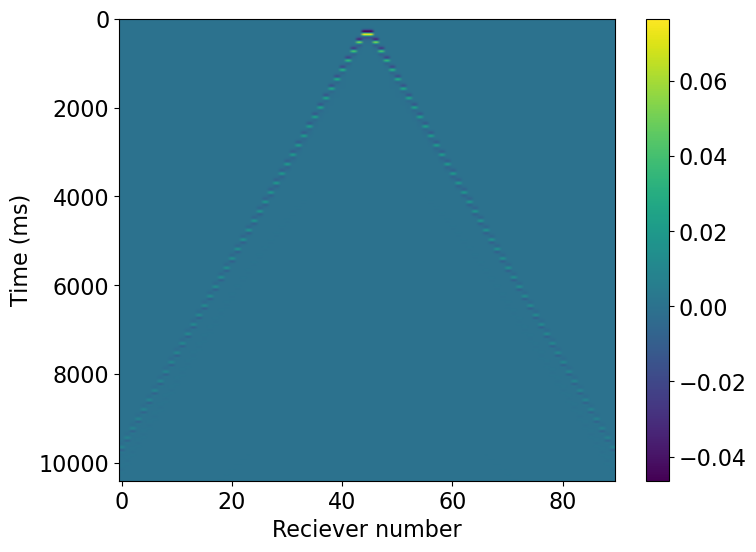

In [176]:
# NBVAL_IGNORE_OUTPUT
plt.imshow(rec.data, cmap='viridis', aspect='auto')
plt.xlabel("Reciever number")
plt.ylabel("Time (ms)")
plt.colorbar()
plt.show()

Após executar o kernel do operador, os dados associados ao símbolo do receptor `rec.data` agora foram preenchidos devido à expressão de interpolação que inserimos no operador. Isso nos permite visualizar o registro sísmico (shot record):

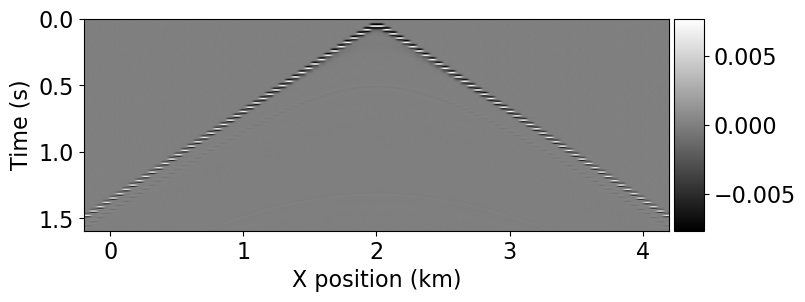

In [177]:
plot_shotrecord(rec.data, model, t0, tn)

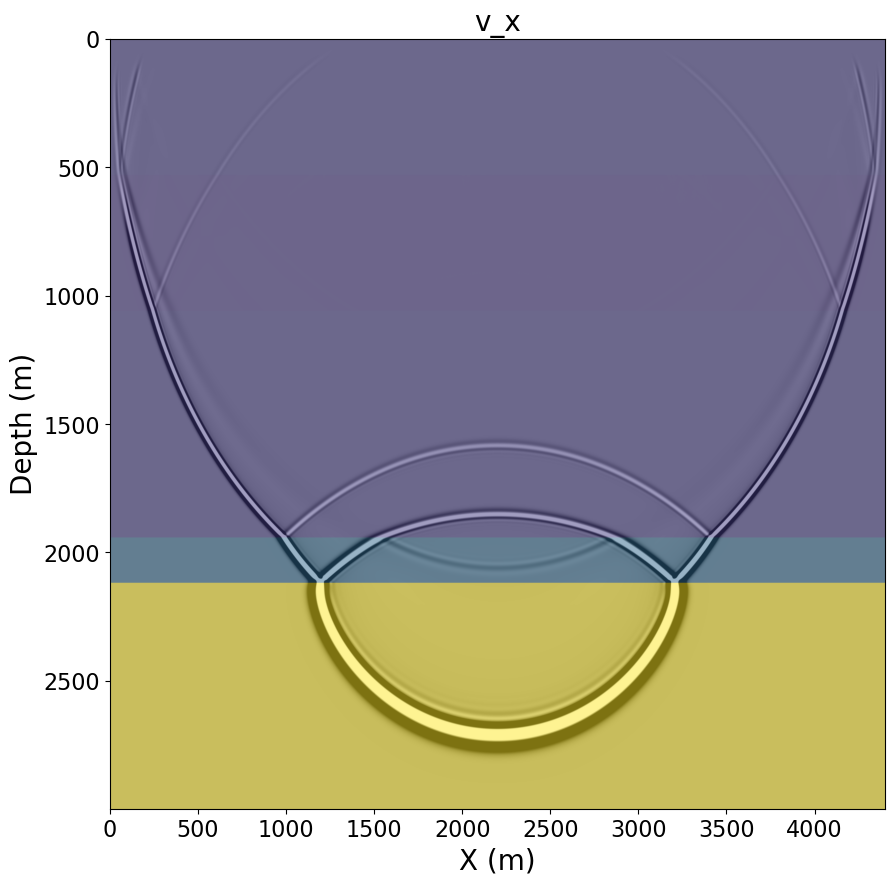

In [178]:
scale = abs(u.data.min())/5

plt_options_model = {'extent': [model.origin[0] , model.origin[0] + model.domain_size[0],
                                model.origin[1] + model.domain_size[1], model.origin[1]]}

slices = [slice(model.nbl, -model.nbl), slice(model.nbl, -model.nbl)]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

ax.imshow(np.transpose(u.data[0]), vmin=-scale, vmax=scale, cmap="Greys_r", **plt_options_model)
ax.imshow(np.transpose(model.vp.data), vmin=1, vmax=4.0, cmap="viridis", alpha=0.5, **plt_options_model)

ax.set_aspect('auto')
ax.set_xlabel('X (m)', fontsize=20)
ax.set_ylabel('Depth (m)', fontsize=20)
ax.set_title('v_x', fontsize=20)
plt.show()

In [179]:
# Se a simulação funcionou corretamente, a norma estará por volta de 370
assert np.isclose(np.linalg.norm(rec.data), 370, rtol=1)  # Passa se 0 < norma < 740
print("Simulação validada com sucesso!")

Simulação validada com sucesso!


/tmp/ipykernel_23619/2851237219.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


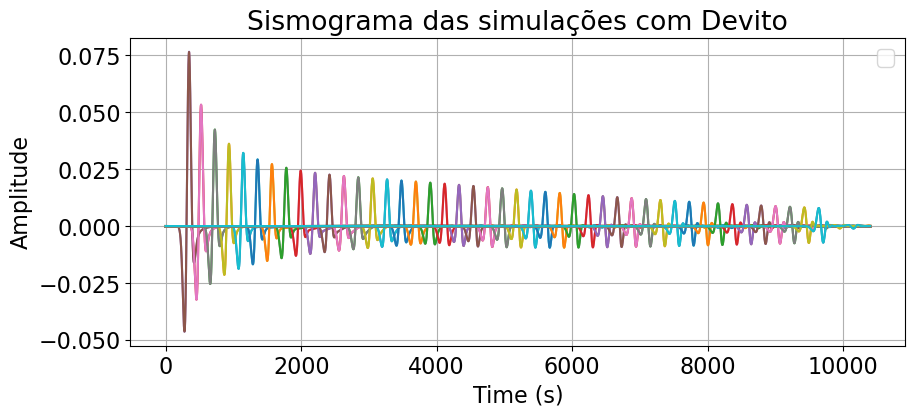

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(rec.data.shape[1]):
    plt.plot(rec.data[:, i])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sismograma das simulações com Devito")
plt.legend()
plt.grid(True)
plt.show()